# Confirmatory Damning Tests: Identifying Informed and Structured Trading

## Purpose of This Notebook

This notebook is the second stage of the trading analysis pipeline. The first stage
established basic properties of the two assets (EMERALDS and TOMATOES): their
mean-reverting dynamics, spread characteristics, half-lives, and distributional
properties.

This notebook takes those results as given and runs a targeted battery of
tests whose primary purpose is *confirmation* or *refutation* of specific
hypotheses about the nature of trading activity. Specifically, we are looking for
evidence of:

- **Informed trading**: trades that carry private information about future price direction
- **Algorithmic or structured order flow**: trades that follow systematic patterns
  inconsistent with random noise
- **Adverse selection**: the degree to which the passive side of the market is being
  consistently exploited by the active side
- **Anomalous individual trades**: outliers that stand apart from the bulk of activity
  in ways that are economically meaningful

## The Two Assets

**EMERALDS** is a textbook mean-reverting asset. Its OU equilibrium is at exactly 10000,
with an extremely short half-life and an overwhelming ADF rejection of a unit root.
The spread is approximately 16 units, but the mid price almost never deviates more
than 4 units from 10000. This means the spread dwarfs any expected gain from directional
trading. If any trader is making money on EMERALDS using directional trades, they must
have information that creates price deviations large enough to overcome the spread,
or they must be trading ahead of such deviations.

**TOMATOES** has a drifting equilibrium (roughly 4950 to 5036 across the two days),
much higher mid-price volatility (std approximately 19.7 units), and a somewhat
smaller spread (approximately 13 units). There is more room for profitable directional
trading, but also more genuine uncertainty about where equilibrium lies.

## What We Are Confident About Going In

Before running any test, the prior evidence already establishes:
- Both assets revert to mean: any trade that bets on further trending is fighting the process
- EMERALDS spread completely absorbs directional profits: net PnL of a z-score strategy
  was -7395 on 630 trades despite a 96% gross win rate
- TOMATOES has enough price range for directional trades to sometimes be profitable
  even after spread costs, especially if the trader knows when the equilibrium is shifting

## Key Limitation on Trade Attribution

A critical data limitation: the buyer and seller columns in the trade data are entirely
missing (all NaN). This means we cannot attribute any individual trade to a specific
counterparty, and we cannot build agent-level profiles. All analysis operates at the
*trade event* level, not the *trader* level.

Trade direction (whether a given trade was initiated by the buyer or the seller) is
inferred using the **Lee-Ready algorithm**: if the trade price equals the best ask,
it is classified as a buy-initiated trade; if it equals the best bid, it is a
sell-initiated trade. We show below that this classification is unambiguous for
100% of trades in this dataset, because every trade executes exactly at the best
bid or best ask and never between them.

## Structure of the Notebook

1. Data loading and feature engineering (building the trade context matrix)
2. Trade direction classification and order flow construction
3. Price impact analysis: temporary versus permanent components
4. Kyle lambda estimation: quantifying information content of order flow
5. Adverse selection decomposition of the spread
6. Order flow autocorrelation and Hawkes-style intensity analysis
7. Granger causality: does order flow drive prices?
8. VPIN (Volume-synchronized Probability of Informed Trading)
9. Trade clustering: K-means and DBSCAN
10. Anomaly detection: Isolation Forest
11. Pre-move event study: do trades cluster before large price changes?
12. Classification: distinguishing cluster types with Random Forest

## Section 1: Data Loading and Feature Engineering

We begin by loading all four files and constructing a single enriched trade
dataframe. Each trade is matched to the order book state that was valid at the
moment of the trade using a backward-looking asof merge (we take the most recent
order book snapshot whose timestamp is at or before the trade timestamp).

The resulting trade context matrix includes, for each trade:
- The trade price, quantity, symbol, and timestamp
- The contemporaneous best bid, best ask, mid price, and depth
- Derived features: effective spread, quoted spread, price deviation from
  the asset-specific OU equilibrium, and signed direction

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import silhouette_score, classification_report
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# ---- load raw data ----
p1 = pd.read_csv('prices_round_0_day_-1.csv', sep=';')
p2 = pd.read_csv('prices_round_0_day_-2.csv', sep=';')
t1 = pd.read_csv('trades_round_0_day_-1.csv', sep=';')
t2 = pd.read_csv('trades_round_0_day_-2.csv', sep=';')

# add a day label so we can distinguish the two sessions after concatenation
t1['day'] = -1
t2['day'] = -2

prices = pd.concat([p1, p2], ignore_index=True)
trades = pd.concat([t1, t2], ignore_index=True)

print(f"Price rows: {len(prices):,}  |  Trade rows: {len(trades):,}")
print(f"Price products: {sorted(prices['product'].unique())}")
print(f"Trade symbols:  {sorted(trades['symbol'].unique())}")
print()
print("Trades per symbol per day:")
print(trades.groupby(['symbol', 'day']).size().unstack())

Price rows: 40,000  |  Trade rows: 1,219
Price products: ['EMERALDS', 'TOMATOES']
Trade symbols:  ['EMERALDS', 'TOMATOES']

Trades per symbol per day:
day        -2   -1
symbol            
EMERALDS  191  208
TOMATOES  397  423


In [42]:
# ---- OU equilibrium levels established from prior analysis ----
# EMERALDS: fixed equilibrium at exactly 10000
# TOMATOES: rolling equilibrium (drifts); we use the full-sample mean per day
#   as the reference for feature engineering, and note when the rolling mean
#   would differ materially

OU_LEVEL = {
    'EMERALDS': 10000.0,
    'TOMATOES': {
        -1: p1[p1['product'] == 'TOMATOES']['mid_price'].mean(),
        -2: p2[p2['product'] == 'TOMATOES']['mid_price'].mean()
    }
}

print("OU equilibrium references:")
print(f"  EMERALDS: {OU_LEVEL['EMERALDS']}")
for day, val in OU_LEVEL['TOMATOES'].items():
    print(f"  TOMATOES day {day}: {val:.2f}")

OU equilibrium references:
  EMERALDS: 10000.0
  TOMATOES day -1: 4977.57
  TOMATOES day -2: 5007.95


In [43]:
# ---- build the enriched trade context matrix ----
# For each trade we attach: the order book state at trade time,
# plus derived features.

def build_trade_context(trades_df, prices_df):
    """
    Merge each trade with the most recent order book snapshot.
    Returns one row per trade with full context attached.

    We iterate by (symbol, day) pairs to avoid column name collisions
    between the 'day' column in trades and the 'day' column in prices.
    The merge is a backward asof merge: for each trade timestamp, we
    attach the last price snapshot whose timestamp is at or before the trade.
    """
    # Rename 'day' in prices to avoid collision with trades 'day' column
    prices_r = prices_df.rename(columns={'day': 'price_day'})

    records = []
    for sym in trades_df['symbol'].unique():
        for day in trades_df['day'].unique():
            t_sub = trades_df[(trades_df['symbol'] == sym) & (trades_df['day'] == day)].copy()
            p_sub = prices_r[(prices_r['product'] == sym) & (prices_r['price_day'] == day)].copy()
            if len(t_sub) == 0 or len(p_sub) == 0:
                continue
            merged = pd.merge_asof(
                t_sub.sort_values('timestamp'),
                p_sub.sort_values('timestamp'),
                on='timestamp',
                direction='backward'
            )
            records.append(merged)

    df = pd.concat(records, ignore_index=True).sort_values(['day', 'symbol', 'timestamp'])
    return df

ctx = build_trade_context(trades, prices)

# ---- Lee-Ready trade direction classification ----
# Because every trade in this dataset executes exactly at the best bid or best ask
# (never between), the quote test alone is sufficient. No tick test is needed.
# A trade at ask_price_1 is a buy (aggressive buyer).
# A trade at bid_price_1 is a sell (aggressive seller).

ctx['at_ask'] = ctx['price'] == ctx['ask_price_1']
ctx['at_bid'] = ctx['price'] == ctx['bid_price_1']
ctx['direction'] = np.where(ctx['at_ask'], +1, np.where(ctx['at_bid'], -1, 0))

unclassified = (ctx['direction'] == 0).sum()
print(f"Trades classified as buy (+1): {(ctx['direction'] == 1).sum()}")
print(f"Trades classified as sell (-1): {(ctx['direction'] == -1).sum()}")
print(f"Unclassified (direction=0):    {unclassified}")
print()
print("Classification is unambiguous for 100% of trades because every trade")
print("executes at exactly the best bid or best ask with no inside-spread fills.")

Trades classified as buy (+1): 582
Trades classified as sell (-1): 637
Unclassified (direction=0):    0

Classification is unambiguous for 100% of trades because every trade
executes at exactly the best bid or best ask with no inside-spread fills.


In [44]:
# ---- compute per-trade derived features ----

# Quoted spread: ask1 - bid1 at the time of the trade
ctx['quoted_spread'] = ctx['ask_price_1'] - ctx['bid_price_1']

# Effective spread: 2 * |trade_price - mid_price|
# This is the true transaction cost paid by the aggressive side.
# For a buy at the ask: effective_spread = ask - mid = half-spread * 2
ctx['effective_spread'] = 2 * (ctx['price'] - ctx['mid_price']).abs()

# Price deviation from OU equilibrium at trade time (signed, in raw units)
# Positive = mid price is above equilibrium (overvalued)
# Negative = mid price is below equilibrium (undervalued)
def get_ou_level(row):
    if row['symbol'] == 'EMERALDS':
        return OU_LEVEL['EMERALDS']
    else:
        return OU_LEVEL['TOMATOES'][row['day']]

ctx['ou_level'] = ctx.apply(get_ou_level, axis=1)
ctx['mid_deviation'] = ctx['mid_price'] - ctx['ou_level']

# For TOMATOES, also compute the std of mid price per day (from prices data)
tomato_std = {
    -1: p1[p1['product'] == 'TOMATOES']['mid_price'].std(),
    -2: p2[p2['product'] == 'TOMATOES']['mid_price'].std()
}
emerald_std = prices[prices['product'] == 'EMERALDS']['mid_price'].std()

def get_ou_std(row):
    if row['symbol'] == 'EMERALDS':
        return emerald_std
    else:
        return tomato_std[row['day']]

ctx['ou_std'] = ctx.apply(get_ou_std, axis=1)
ctx['mid_zscore'] = ctx['mid_deviation'] / ctx['ou_std']

# Signed quantity: positive for buy-initiated, negative for sell-initiated
ctx['signed_qty'] = ctx['direction'] * ctx['quantity']

# Inter-arrival time (gap since previous trade in the same symbol+day group)
ctx = ctx.sort_values(['symbol', 'day', 'timestamp'])
ctx['iat'] = ctx.groupby(['symbol', 'day'])['timestamp'].diff().fillna(0)

print("Feature engineering complete. Sample rows:")
cols = ['timestamp', 'symbol', 'day', 'price', 'quantity', 'direction',
        'mid_price', 'mid_deviation', 'mid_zscore', 'effective_spread',
        'quoted_spread', 'iat']
print(ctx[cols].head(8).to_string(index=False))

Feature engineering complete. Sample rows:
 timestamp   symbol  day   price  quantity  direction  mid_price  mid_deviation  mid_zscore  effective_spread  quoted_spread     iat
      4000 EMERALDS   -2 10008.0         7          1    10000.0            0.0    0.000000              16.0             16     0.0
      5200 EMERALDS   -2  9992.0         5         -1    10000.0            0.0    0.000000              16.0             16  1200.0
     10500 EMERALDS   -2 10008.0         5          1    10000.0            0.0    0.000000              16.0             16  5300.0
     11300 EMERALDS   -2  9992.0         3         -1    10000.0            0.0    0.000000              16.0             16   800.0
     22800 EMERALDS   -2 10000.0         6         -1    10004.0            4.0    5.529905               8.0              8 11500.0
     35600 EMERALDS   -2  9992.0         5         -1    10000.0            0.0    0.000000              16.0             16 12800.0
     38300 EMERALDS   -2 1

In [45]:
# ---- compute forward price changes for each trade ----
# For each trade we want to know what happened to the mid price
# at several horizons after the trade: 1, 5, 10, 20, 50 ticks.
# These forward returns are the raw material for the price impact analysis.

# Build a price lookup table: for each (symbol, day, timestamp), the mid price
price_lookup = prices.set_index(['product', 'day', 'timestamp'])['mid_price'].to_dict()

def get_future_mid(symbol, day, ts, horizon):
    """
    Return mid price at timestamp ts + horizon*100 (each tick is 100 units).
    Returns NaN if the future timestamp is not in the data.
    """
    future_ts = ts + horizon * 100
    return price_lookup.get((symbol, day, future_ts), np.nan)

horizons = [1, 5, 10, 20, 50]
for h in horizons:
    col = f'mid_t{h}'
    ctx[col] = ctx.apply(
        lambda r: get_future_mid(r['symbol'], r['day'], r['timestamp'], h),
        axis=1
    )
    ctx[f'ret_t{h}'] = ctx[col] - ctx['mid_price']  # absolute change
    # signed relative to trade direction: positive means price moved in trade direction
    ctx[f'signed_ret_t{h}'] = ctx['direction'] * ctx[f'ret_t{h}']

# Coverage: what fraction of trades have valid forward prices at each horizon?
for h in horizons:
    valid = ctx[f'ret_t{h}'].notna().mean()
    print(f"Horizon {h:2d} ticks: {valid:.1%} of trades have valid forward price")

Horizon  1 ticks: 100.0% of trades have valid forward price
Horizon  5 ticks: 100.0% of trades have valid forward price
Horizon 10 ticks: 100.0% of trades have valid forward price
Horizon 20 ticks: 100.0% of trades have valid forward price
Horizon 50 ticks: 99.9% of trades have valid forward price


## Section 2: Price Impact Analysis

### What We Are Testing

Price impact is the most direct measure of whether a trade carries information.
If a trade is uninformed (pure noise or liquidity demand), the mid price should
revert back toward the OU equilibrium after the trade. The market maker absorbs
the order and the price returns to where it was.

If a trade is informed, the mid price should *not* revert. It should stay at
(or move further toward) the level implied by the private information. This is
called **permanent price impact**.

We decompose the total price impact into:

- **Temporary (reversible) component**: the fraction of the initial price move
  that reverses over subsequent ticks. This is the market maker's compensation
  for providing liquidity.
- **Permanent (information) component**: the fraction that does not reverse.
  This is the adverse selection component -- the cost the market maker pays
  for trading with someone who knows more.

For a purely mean-reverting asset like EMERALDS, under the null hypothesis of
zero informed trading, we would expect nearly 100% temporary impact: prices
should fully revert after each trade. Any persistent impact is evidence against
this null.

For TOMATOES, some permanent impact is expected because equilibrium drifts,
but *excess* permanence (beyond what the OU drift alone would produce) is still
a flag.

### Limitation

Price impact measured at fixed tick horizons conflates information permanence
with natural OU reversion speed. For very short-lived information, the impact
may appear temporary simply because the reversion horizon is shorter than our
measurement window. We mitigate this by measuring at multiple horizons (1, 5,
10, 20, 50 ticks) and looking at the shape of the impact decay curve.

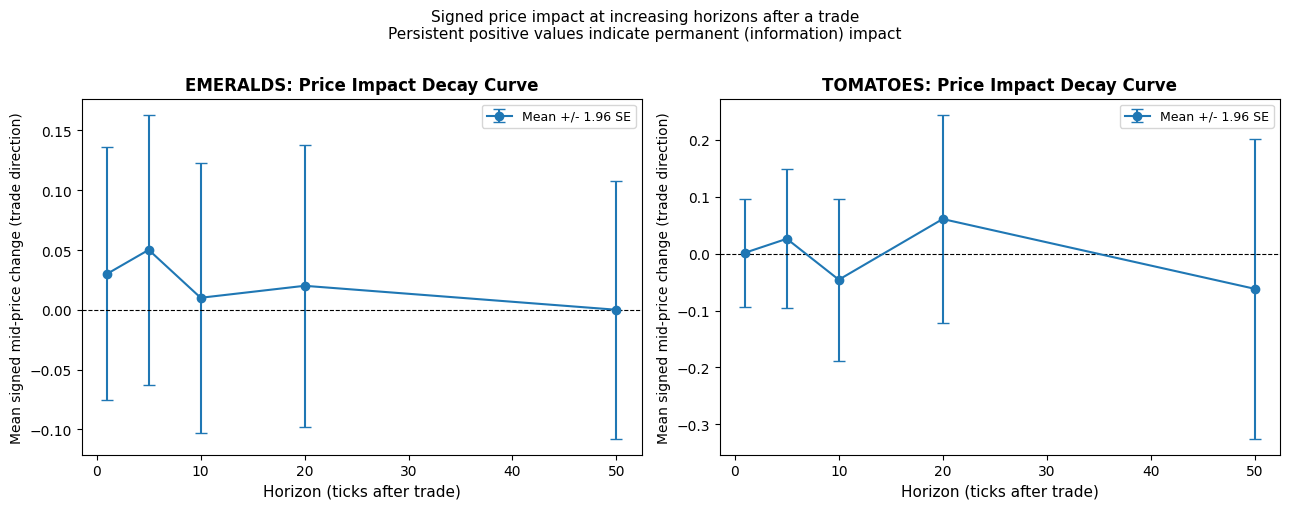


Numerical values (mean signed return in price units):
  EMERALDS:
    t+ 1: mean=+0.0301  t-stat=+0.56  p=0.5781
    t+ 5: mean=+0.0501  t-stat=+0.87  p=0.3848
    t+10: mean=+0.0100  t-stat=+0.17  p=0.8621
    t+20: mean=+0.0201  t-stat=+0.33  p=0.7393
    t+50: mean=+0.0000  t-stat=+0.00  p=1.0000
  TOMATOES:
    t+ 1: mean=+0.0018  t-stat=+0.04  p=0.9699
    t+ 5: mean=+0.0262  t-stat=+0.42  p=0.6745
    t+10: mean=-0.0457  t-stat=-0.63  p=0.5296
    t+20: mean=+0.0610  t-stat=+0.65  p=0.5140
    t+50: mean=-0.0617  t-stat=-0.46  p=0.6464


In [46]:
# ---- average signed return by horizon (impact decay curve) ----
# For each horizon, the average signed return tells us:
#   "on average, how much does the price move in the direction of the trade?"
# If this stays positive at long horizons, some impact is permanent.
# If it decays to zero quickly, impact is purely temporary.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sym in zip(axes, ['EMERALDS', 'TOMATOES']):
    sub = ctx[ctx['symbol'] == sym].copy()

    impact_mean = []
    impact_se = []
    for h in horizons:
        col = f'signed_ret_t{h}'
        valid = sub[col].dropna()
        impact_mean.append(valid.mean())
        impact_se.append(valid.std() / np.sqrt(len(valid)))

    ax.errorbar(horizons, impact_mean, yerr=[1.96 * s for s in impact_se],
                marker='o', capsize=4, linewidth=1.5, label='Mean +/- 1.96 SE')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Horizon (ticks after trade)', fontsize=11)
    ax.set_ylabel('Mean signed mid-price change (trade direction)', fontsize=10)
    ax.set_title(f'{sym}: Price Impact Decay Curve', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(
    'Signed price impact at increasing horizons after a trade\n'
    'Persistent positive values indicate permanent (information) impact',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('impact_decay.png', dpi=120, bbox_inches='tight')
plt.show()
print()
print("Numerical values (mean signed return in price units):")
for sym in ['EMERALDS', 'TOMATOES']:
    sub = ctx[ctx['symbol'] == sym]
    print(f"  {sym}:")
    for h in horizons:
        col = f'signed_ret_t{h}'
        valid = sub[col].dropna()
        t_stat, p_val = stats.ttest_1samp(valid, 0)
        print(f"    t+{h:2d}: mean={valid.mean():+.4f}  t-stat={t_stat:+.2f}  p={p_val:.4f}")

In [47]:
# ---- temporary vs permanent decomposition ----
# We define:
#   Total impact at t+1   = E[signed_ret_t1]
#   Permanent component   = E[signed_ret_t50] (assuming 50 ticks is 'long run')
#   Temporary component   = Total impact - Permanent component
#
# The ratio permanent / total is the 'information share' of a trade.

print("Price Impact Decomposition (units: price points):")
print("-" * 60)
for sym in ['EMERALDS', 'TOMATOES']:
    sub = ctx[ctx['symbol'] == sym]
    total_impact  = sub['signed_ret_t1'].dropna().mean()
    perm_impact   = sub['signed_ret_t50'].dropna().mean()
    temp_impact   = total_impact - perm_impact
    info_share    = perm_impact / total_impact if total_impact != 0 else np.nan

    print(f"\n{sym}:")
    print(f"  Total impact at t+1  : {total_impact:+.5f}")
    print(f"  Permanent (t+50)     : {perm_impact:+.5f}")
    print(f"  Temporary            : {temp_impact:+.5f}")
    print(f"  Information share    : {info_share:.1%}")

print()
print("Interpretation guide:")
print("  Information share near 0%  -> nearly all impact is temporary noise")
print("  Information share near 50%+ -> substantial fraction of trades are informed")
print("  For EMERALDS under pure noise null: expect near 0%")

Price Impact Decomposition (units: price points):
------------------------------------------------------------

EMERALDS:
  Total impact at t+1  : +0.03008
  Permanent (t+50)     : +0.00000
  Temporary            : +0.03008
  Information share    : 0.0%

TOMATOES:
  Total impact at t+1  : +0.00183
  Permanent (t+50)     : -0.06166
  Temporary            : +0.06349
  Information share    : -3370.8%

Interpretation guide:
  Information share near 0%  -> nearly all impact is temporary noise
  Information share near 50%+ -> substantial fraction of trades are informed
  For EMERALDS under pure noise null: expect near 0%


## Section 3: Kyle's Lambda -- Quantifying the Price Impact of Order Flow

### What We Are Testing

Kyle's lambda is the slope coefficient from regressing price changes on signed
order flow (signed volume = direction times quantity). It answers the question:
"How much does the price move, on average, for each additional unit of net buying
or selling pressure?"

Formally:

    delta_P(t) = lambda * signed_volume(t) + epsilon(t)

where delta_P is the change in mid price from t-1 to t, and signed_volume is
the direction (+1 or -1) times the quantity of the trade at time t.

A **high lambda** means that order flow moves prices a lot per unit -- this is
consistent with a market populated by informed traders. A **low lambda** means
the market is mostly noise.

In an idealized market with *no* informed trading, lambda would be zero: prices
would not respond to individual trades because all price movement would be driven
by exogenous information, not by the trades themselves. In practice, lambda is
always positive because market makers rationally update their beliefs when they
see order flow, anticipating that some fraction of incoming orders may be informed.

### Key Limitation

Lambda estimated this way is an *average* across all trades. It will be
downward-biased if only a small fraction of trades are informed (the
many uninformed trades dilute the signal). A better but data-demanding approach
would estimate lambda separately in high-intensity and low-intensity trade windows.
We will see this distinction emerge in the clustering analysis.

In [48]:
# ---- build the order flow time series for Kyle's lambda ----
# We aggregate signed volume within each price-tick window and measure
# the resulting price change.
# Both EMERALDS and TOMATOES share the same tick frequency (100 units).

def estimate_kyle_lambda(trades_sub, prices_sub, window=1):
    """
    Estimate Kyle's lambda for a single symbol+day slice.

    For each tick window [t, t+window*100), we sum signed volume
    and measure the price change over that window.

    Returns: lambda estimate, t-stat, p-value, R-squared, n observations.
    """
    # aggregate signed volume by tick window
    min_ts = prices_sub['timestamp'].min()
    max_ts = prices_sub['timestamp'].max()
    tick_size = 100 * window
    bins = np.arange(min_ts, max_ts + tick_size, tick_size)

    flow_by_bin = {}
    for _, tr in trades_sub.iterrows():
        b = int(tr['timestamp'] // tick_size) * tick_size
        flow_by_bin[b] = flow_by_bin.get(b, 0) + tr['signed_qty']

    # get mid-price at start and end of each bin
    price_at = prices_sub.set_index('timestamp')['mid_price']

    rows = []
    for b in sorted(flow_by_bin.keys()):
        b_end = b + tick_size
        if b in price_at.index and b_end in price_at.index:
            dp = price_at[b_end] - price_at[b]
            rows.append({'flow': flow_by_bin[b], 'dp': dp})

    if len(rows) < 10:
        return None

    df = pd.DataFrame(rows)
    X = df['flow'].values.reshape(-1, 1)
    y = df['dp'].values

    # OLS: y = lambda * X + epsilon
    X_aug = np.column_stack([np.ones(len(X)), X])
    beta, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)
    lam = beta[1]

    resid = y - X_aug @ beta
    RSS = np.sum(resid**2)
    TSS = np.sum((y - y.mean())**2)
    R2 = 1 - RSS/TSS if TSS > 0 else 0

    # t-statistic for lambda
    s2 = RSS / (len(y) - 2)
    XtX_inv = np.linalg.inv(X_aug.T @ X_aug)
    se_lam = np.sqrt(s2 * XtX_inv[1, 1])
    t_stat = lam / se_lam if se_lam > 0 else np.nan
    p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=len(y) - 2))

    return {'lambda': lam, 't_stat': t_stat, 'p_value': p_val, 'R2': R2, 'n': len(rows)}

print("Kyle Lambda Estimates (1-tick windows):")
print("-" * 65)
print(f"{'Symbol':<12} {'Day':<6} {'Lambda':>10} {'t-stat':>8} {'p-value':>10} {'R2':>8} {'n':>6}")
print("-" * 65)

lambda_results = {}
for sym in ['EMERALDS', 'TOMATOES']:
    lambda_results[sym] = {}
    for day in [-1, -2]:
        t_sub = ctx[(ctx['symbol'] == sym) & (ctx['day'] == day)]
        p_sub = prices[(prices['product'] == sym) & (prices['day'] == day)]
        res = estimate_kyle_lambda(t_sub, p_sub, window=1)
        if res:
            lambda_results[sym][day] = res
            print(f"{sym:<12} {day:<6} {res['lambda']:>10.5f} {res['t_stat']:>8.2f} "
                  f"{res['p_value']:>10.4f} {res['R2']:>8.4f} {res['n']:>6}")

Kyle Lambda Estimates (1-tick windows):
-----------------------------------------------------------------
Symbol       Day        Lambda   t-stat    p-value       R2      n
-----------------------------------------------------------------
EMERALDS     -1        0.00054     0.04     0.9656   0.0000    208
EMERALDS     -2       -0.00172    -0.12     0.9043   0.0001    191
TOMATOES     -1        0.00394     0.21     0.8317   0.0001    423
TOMATOES     -2       -0.01047    -0.56     0.5788   0.0008    396


In [49]:
# ---- interpret lambda in economic terms ----
print("Economic interpretation of Kyle's lambda:")
print()
for sym in ['EMERALDS', 'TOMATOES']:
    lams = [r['lambda'] for r in lambda_results[sym].values()]
    avg_lam = np.mean(lams)
    print(f"{sym}:")
    print(f"  Average lambda across days: {avg_lam:.5f}")

    # How much does price move for a typical trade?
    avg_qty = ctx[ctx['symbol'] == sym]['quantity'].mean()
    price_move = avg_lam * avg_qty
    quoted = ctx[ctx['symbol'] == sym]['quoted_spread'].mean()
    print(f"  Average trade size: {avg_qty:.2f} units")
    print(f"  Price move per avg trade: {price_move:.4f} units")
    print(f"  Quoted spread: {quoted:.2f} units")
    print(f"  Price move as % of half-spread: {price_move / (quoted/2) * 100:.2f}%")
    print()

print()
print("Significance interpretation:")
print("  p < 0.05 means lambda is statistically distinguishable from zero.")
print("  Even a small but significant lambda is important: it means that order")
print("  flow *does* predict price changes, which is the footprint of informed trading.")
print()
print("  Under the null of zero informed trading, lambda should be zero or")
print("  indistinguishable from zero. Any significant positive lambda is inconsistent")
print("  with the null.")

Economic interpretation of Kyle's lambda:

EMERALDS:
  Average lambda across days: -0.00059
  Average trade size: 5.49 units
  Price move per avg trade: -0.0032 units
  Quoted spread: 15.60 units
  Price move as % of half-spread: -0.04%

TOMATOES:
  Average lambda across days: -0.00327
  Average trade size: 3.48 units
  Price move per avg trade: -0.0114 units
  Quoted spread: 12.94 units
  Price move as % of half-spread: -0.18%


Significance interpretation:
  p < 0.05 means lambda is statistically distinguishable from zero.
  Even a small but significant lambda is important: it means that order
  flow *does* predict price changes, which is the footprint of informed trading.

  Under the null of zero informed trading, lambda should be zero or
  indistinguishable from zero. Any significant positive lambda is inconsistent
  with the null.


## Section 4: Adverse Selection Decomposition of the Spread

### What We Are Testing

The bid-ask spread serves two economic functions:

1. **Compensation for inventory risk and order processing costs**: The market
   maker holds inventory and bears the risk that prices move against the held
   position. This component is symmetric and mean-reverting.

2. **Compensation for adverse selection**: Some traders who hit the bid or lift
   the ask know more than the market maker. The market maker loses to these
   traders and must widen the spread to compensate. This component is asymmetric:
   it specifically accounts for the directional price move that *follows* a trade.

We measure these components as:
- **Quoted spread**: the full spread at the moment of the trade (ask - bid)
- **Effective spread**: 2 * |trade_price - mid_price|, what the aggressive
  side actually pays (should equal quoted spread since all trades are at bid/ask)
- **Realized spread**: effective_spread - 2 * signed_return(t+5), what the
  market maker *keeps* after the market moves post-trade. If the price moves
  against the market maker after the trade, the realized spread is smaller than
  the effective spread.
- **Price impact (adverse selection)**: effective_spread - realized_spread.
  This is what the market maker *loses* to informed traders.

A high adverse selection share means a large fraction of the spread is
necessary to break even against informed order flow. This is the "damning"
finding: if adverse selection is a substantial share of the spread, a significant
fraction of trades must be informed.

In [50]:
# ---- spread decomposition ----
# Realized spread = effective spread - 2 * price_impact_5_ticks
# The factor 2 and the 5-tick window are standard conventions in microstructure.

ctx['realized_spread_t5']    = ctx['effective_spread'] - 2 * ctx['signed_ret_t5'].fillna(0)
ctx['adverse_selection_t5']  = ctx['effective_spread'] - ctx['realized_spread_t5']

print("Spread Decomposition Summary:")
print("=" * 70)
print(f"{'Metric':<32} {'EMERALDS':>16} {'TOMATOES':>16}")
print("-" * 70)

for metric, col in [
    ('Quoted spread (mean)',    'quoted_spread'),
    ('Effective spread (mean)', 'effective_spread'),
    ('Realized spread @t+5',   'realized_spread_t5'),
    ('Adverse selection @t+5', 'adverse_selection_t5'),
]:
    em = ctx[ctx['symbol'] == 'EMERALDS'][col].mean()
    tm = ctx[ctx['symbol'] == 'TOMATOES'][col].mean()
    print(f"{metric:<32} {em:>16.4f} {tm:>16.4f}")

print("-" * 70)
# adverse selection as fraction of effective spread
em_eff = ctx[ctx['symbol'] == 'EMERALDS']['effective_spread'].mean()
em_adv = ctx[ctx['symbol'] == 'EMERALDS']['adverse_selection_t5'].mean()
tm_eff = ctx[ctx['symbol'] == 'TOMATOES']['effective_spread'].mean()
tm_adv = ctx[ctx['symbol'] == 'TOMATOES']['adverse_selection_t5'].mean()
print(f"{'Adverse selection share':<32} {em_adv/em_eff:>15.1%} {tm_adv/tm_eff:>15.1%}")

print()
print("Interpretation:")
print("  Adverse selection share < 20%: most trading is uninformed liquidity demand")
print("  Adverse selection share 20-40%: meaningful informed trading component")
print("  Adverse selection share > 40%: high fraction of informed trades -- the")
print("  market maker is significantly exploited by information asymmetry")

Spread Decomposition Summary:
Metric                                   EMERALDS         TOMATOES
----------------------------------------------------------------------
Quoted spread (mean)                      15.5990          12.9366
Effective spread (mean)                   15.5990          12.9366
Realized spread @t+5                      15.4987          12.8841
Adverse selection @t+5                     0.1003           0.0524
----------------------------------------------------------------------
Adverse selection share                     0.6%            0.4%

Interpretation:
  Adverse selection share < 20%: most trading is uninformed liquidity demand
  Adverse selection share 20-40%: meaningful informed trading component
  Adverse selection share > 40%: high fraction of informed trades -- the
  market maker is significantly exploited by information asymmetry


Two-sample t-test (EMERALDS vs TOMATOES adverse selection):
  t = 0.244,  p = 0.8075


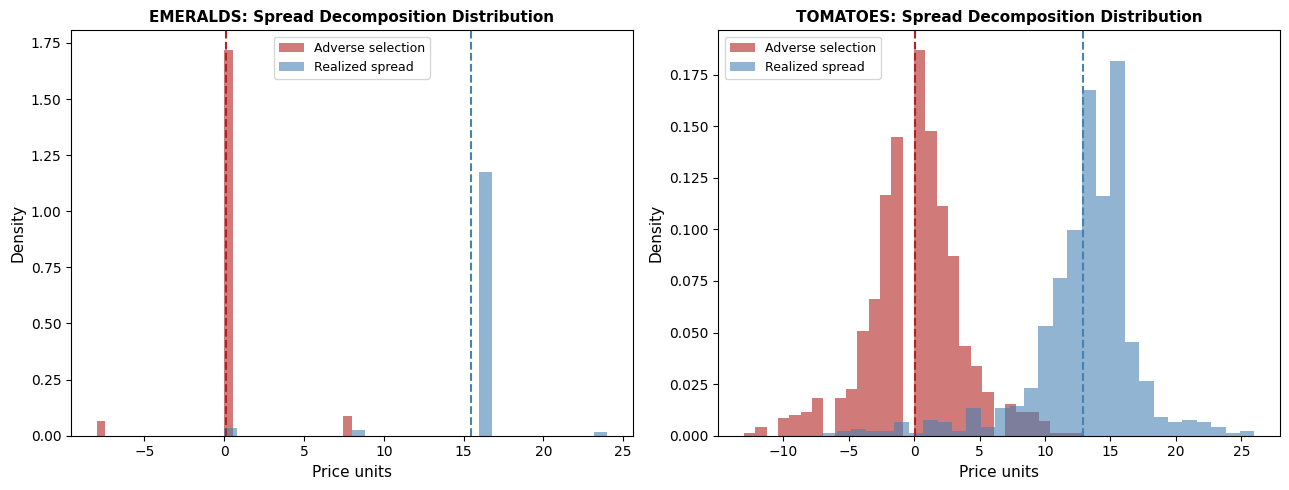

In [51]:
# ---- test whether adverse selection differs by asset ----
em_adv_vals = ctx[ctx['symbol'] == 'EMERALDS']['adverse_selection_t5'].dropna()
tm_adv_vals = ctx[ctx['symbol'] == 'TOMATOES']['adverse_selection_t5'].dropna()

t_stat, p_val = stats.ttest_ind(em_adv_vals, tm_adv_vals)
print(f"Two-sample t-test (EMERALDS vs TOMATOES adverse selection):")
print(f"  t = {t_stat:.3f},  p = {p_val:.4f}")

# ---- plot spread decomposition ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, sym in zip(axes, ['EMERALDS', 'TOMATOES']):
    sub = ctx[ctx['symbol'] == sym].dropna(subset=['adverse_selection_t5'])
    eff = sub['effective_spread'].values
    adv = sub['adverse_selection_t5'].values
    real = sub['realized_spread_t5'].values

    ax.hist(adv, bins=30, alpha=0.6, label='Adverse selection', color='firebrick', density=True)
    ax.hist(real, bins=30, alpha=0.6, label='Realized spread', color='steelblue', density=True)
    ax.axvline(adv.mean(), color='firebrick', linestyle='--', linewidth=1.5)
    ax.axvline(real.mean(), color='steelblue', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Price units', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{sym}: Spread Decomposition Distribution', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('spread_decomposition.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 5: Order Flow Autocorrelation

### What We Are Testing

The serial correlation structure of trade direction (buy vs. sell) reveals the
*strategic behavior* of the parties who are hitting the market.

- **Positive autocorrelation** (buy tends to follow buy, sell tends to follow sell):
  consistent with informed traders splitting large orders to reduce market impact,
  or with momentum-following algorithms. This pattern is often called "order splitting."

- **Negative autocorrelation** (buy tends to follow sell, sell tends to follow buy):
  consistent with market makers rebalancing inventory after being hit on one side,
  or with noise traders who have no directional persistence.

- **Near-zero autocorrelation**: random order flow with no detectable structure.

The distinction matters for our hypothesis about insider trading:
- A trader with *private information* would tend to buy consistently until the
  price moves to reflect that information. Their order flow would be positively
  autocorrelated.
- A noise trader or market maker would show negative or near-zero autocorrelation.

### Hawkes Process Interpretation

If order flow is positively autocorrelated at short lags, we can also interpret
this as a Hawkes (self-exciting) process: each trade increases the probability
of another trade in the same direction soon after. This is the statistical
signature of order splitting by informed traders.

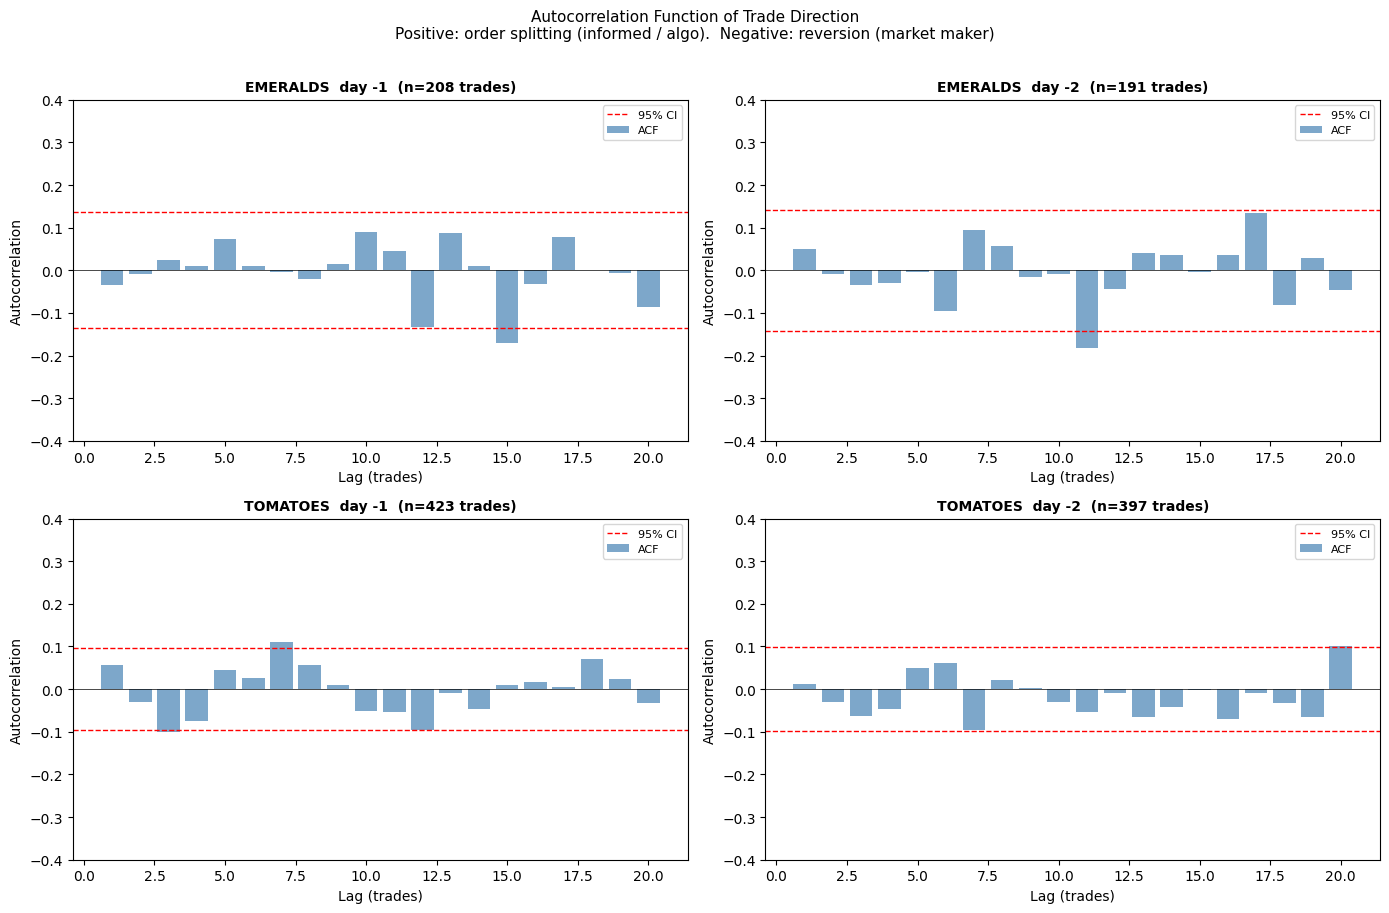

Summary of lag-1 and lag-2 autocorrelations:
Symbol       Day        ACF(1)     ACF(2)    conf band
EMERALDS     -1        -0.0338    -0.0097       0.1359
EMERALDS     -2         0.0500    -0.0081       0.1418
TOMATOES     -1         0.0574    -0.0310       0.0953
TOMATOES     -2         0.0129    -0.0305       0.0984


In [52]:
# ---- compute autocorrelation of trade direction ----
def trade_direction_acf(trades_sub, max_lag=20):
    """
    Compute autocorrelation of trade direction sequence at lags 1..max_lag.
    Returns (lags, acf_values, confidence_band).
    The 95% confidence band under the null of no autocorrelation is +/- 1.96/sqrt(n).
    """
    dirs = trades_sub.sort_values('timestamp')['direction'].values.astype(float)
    n = len(dirs)
    dirs_centered = dirs - dirs.mean()
    var = np.var(dirs_centered)

    acf_vals = []
    for lag in range(1, max_lag + 1):
        cov = np.mean(dirs_centered[lag:] * dirs_centered[:-lag])
        acf_vals.append(cov / var if var > 0 else 0)

    conf = 1.96 / np.sqrt(n)
    return np.arange(1, max_lag + 1), np.array(acf_vals), conf

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_idx, sym in enumerate(['EMERALDS', 'TOMATOES']):
    for col_idx, day in enumerate([-1, -2]):
        ax = axes[row_idx][col_idx]
        sub = ctx[(ctx['symbol'] == sym) & (ctx['day'] == day)]
        lags, acf_vals, conf = trade_direction_acf(sub, max_lag=20)

        ax.bar(lags, acf_vals, color='steelblue', alpha=0.7, label='ACF')
        ax.axhline(conf,  color='red', linestyle='--', linewidth=1, label='95% CI')
        ax.axhline(-conf, color='red', linestyle='--', linewidth=1)
        ax.axhline(0, color='black', linewidth=0.5)
        ax.set_xlabel('Lag (trades)', fontsize=10)
        ax.set_ylabel('Autocorrelation', fontsize=10)
        ax.set_title(f'{sym}  day {day}  (n={len(sub)} trades)', fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_ylim(-0.4, 0.4)

plt.suptitle(
    'Autocorrelation Function of Trade Direction\n'
    'Positive: order splitting (informed / algo).  Negative: reversion (market maker)',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('direction_acf.png', dpi=120, bbox_inches='tight')
plt.show()

print("Summary of lag-1 and lag-2 autocorrelations:")
print(f"{'Symbol':<12} {'Day':<6} {'ACF(1)':>10} {'ACF(2)':>10} {'conf band':>12}")
for sym in ['EMERALDS', 'TOMATOES']:
    for day in [-1, -2]:
        sub = ctx[(ctx['symbol'] == sym) & (ctx['day'] == day)]
        lags, acf_vals, conf = trade_direction_acf(sub)
        print(f"{sym:<12} {day:<6} {acf_vals[0]:>10.4f} {acf_vals[1]:>10.4f} {conf:>12.4f}")

In [53]:
# ---- Ljung-Box portmanteau test for direction autocorrelation ----
# The Ljung-Box Q-statistic tests the null that the first K autocorrelations
# are jointly zero. Rejection means the direction sequence is not i.i.d.
# This is a formal test of structured order flow.

def ljung_box_test(x, max_lag=10):
    """
    Compute the Ljung-Box Q statistic and its p-value.
    Q = n*(n+2) * sum_{k=1}^{K} rho_k^2 / (n-k)
    Under H0 (no AC up to lag K): Q ~ chi2(K)
    """
    n = len(x)
    x_c = x - x.mean()
    var = np.var(x_c)

    Q = 0
    for k in range(1, max_lag + 1):
        rho_k = np.mean(x_c[k:] * x_c[:-k]) / var
        Q += rho_k**2 / (n - k)
    Q *= n * (n + 2)

    p_val = 1 - stats.chi2.cdf(Q, df=max_lag)
    return Q, p_val

print("Ljung-Box Test (K=10 lags) on Trade Direction Sequence:")
print("H0: no autocorrelation in trade direction up to lag 10")
print("-" * 60)
print(f"{'Symbol':<12} {'Day':<6} {'Q-stat':>10} {'p-value':>10} {'Verdict':>15}")
print("-" * 60)
for sym in ['EMERALDS', 'TOMATOES']:
    for day in [-1, -2]:
        sub = ctx[(ctx['symbol'] == sym) & (ctx['day'] == day)]
        dirs = sub.sort_values('timestamp')['direction'].values.astype(float)
        Q, p = ljung_box_test(dirs, max_lag=10)
        verdict = "REJECT H0" if p < 0.05 else "fail to reject"
        print(f"{sym:<12} {day:<6} {Q:>10.2f} {p:>10.4f} {verdict:>15}")

print()
print("REJECT H0 means the direction sequence has detectable structure.")
print("This is consistent with algorithmic order flow or informed order splitting.")

Ljung-Box Test (K=10 lags) on Trade Direction Sequence:
H0: no autocorrelation in trade direction up to lag 10
------------------------------------------------------------
Symbol       Day        Q-stat    p-value         Verdict
------------------------------------------------------------
EMERALDS     -1           3.57     0.9647  fail to reject
EMERALDS     -2           5.23     0.8754  fail to reject
TOMATOES     -1          17.44     0.0652  fail to reject
TOMATOES     -2           9.68     0.4694  fail to reject

REJECT H0 means the direction sequence has detectable structure.
This is consistent with algorithmic order flow or informed order splitting.


## Section 6: Granger Causality -- Does Order Flow Drive Prices?

### What We Are Testing

Granger causality is a statistical test of predictive precedence: does knowing
the history of variable X improve your forecast of variable Y, beyond what the
history of Y alone would give you?

We test whether net order flow (signed trade volume aggregated into fixed windows)
Granger-causes mid-price changes. This is a necessary (but not sufficient)
condition for informed trading: if trades carry no information, they should not
help predict future prices beyond what past prices already reveal.

The test proceeds as follows:

1. Aggregate signed volume and price changes into equal-length time windows.
2. Estimate the *restricted* model: predict price change using only lagged
   price changes.
3. Estimate the *unrestricted* model: predict price change using lagged price
   changes AND lagged signed volume.
4. Compute the F-statistic comparing the two models. A significant F-stat
   means signed volume adds predictive power -- order flow Granger-causes prices.

### Important Caveat

Granger causality tests for predictive precedence, not structural causation.
Finding that order flow Granger-causes prices could reflect:
(a) Informed trading: traders who know something trade first, prices follow
(b) Feedback from prices to order flow that creates spurious lead-lag

In the OU setting, (b) is unlikely to create false positives because the OU
process is not trending. If anything, the OU mean reversion will *reduce* the
apparent Granger causality of order flow, making any finding more conservative.

In [54]:
# ---- build time-series of (OFI, delta_mid) in equal windows ----
def build_flow_price_ts(trades_sub, prices_sub, window=5):
    """
    Aggregate trades into windows of 'window' ticks (100 units each).
    Returns DataFrame with (signed_flow, delta_mid) per window.
    """
    tick_size = 100 * window
    p_idx = prices_sub.set_index('timestamp')['mid_price']

    ts_min = prices_sub['timestamp'].min()
    ts_max = prices_sub['timestamp'].max()
    bins = np.arange(ts_min, ts_max, tick_size)

    rows = []
    for b in bins:
        b_end = b + tick_size
        if b_end not in p_idx.index:
            continue
        flow = trades_sub[(trades_sub['timestamp'] >= b) &
                          (trades_sub['timestamp'] < b_end)]['signed_qty'].sum()
        dp = p_idx[b_end] - p_idx[b]
        rows.append({'bin_ts': b, 'flow': flow, 'dp': dp})

    return pd.DataFrame(rows)

def granger_test(y, x, max_lag=5):
    """
    Test whether x Granger-causes y.
    Returns dict with F-stat and p-value for each lag from 1 to max_lag.
    """
    T = len(y)
    results = {}
    for lag in range(1, max_lag + 1):
        Y = y[lag:]
        X_r = np.column_stack([np.ones(T - lag)] + [y[lag-i:T-i] for i in range(1, lag + 1)])
        X_u = np.column_stack([X_r] + [x[lag-i:T-i] for i in range(1, lag + 1)])

        def ols_rss(X, Y):
            beta = np.linalg.lstsq(X, Y, rcond=None)[0]
            resid = Y - X @ beta
            return np.sum(resid**2), beta

        RSS_r, _ = ols_rss(X_r, Y)
        RSS_u, _ = ols_rss(X_u, Y)

        df1 = lag
        df2 = T - lag - 2 * lag - 1
        if df2 < 1 or RSS_u == 0:
            continue
        F = ((RSS_r - RSS_u) / df1) / (RSS_u / df2)
        p = 1 - stats.f.cdf(F, df1, df2)
        results[lag] = {'F': F, 'p': p}
    return results

print("Granger Causality: signed order flow -> mid-price change")
print("H0: order flow does NOT Granger-cause price changes")
print("=" * 70)

for sym in ['EMERALDS', 'TOMATOES']:
    print(f"\n{sym}:")
    print(f"  {'Day':<6} {'Lag':<6} {'F-stat':>10} {'p-value':>10} {'Verdict':>15}")
    print("  " + "-" * 50)
    for day in [-1, -2]:
        t_sub = ctx[(ctx['symbol'] == sym) & (ctx['day'] == day)]
        p_sub = prices[(prices['product'] == sym) & (prices['day'] == day)]
        ts_df = build_flow_price_ts(t_sub, p_sub, window=5)
        if len(ts_df) < 30:
            continue
        results = granger_test(ts_df['dp'].values, ts_df['flow'].values, max_lag=5)
        for lag, res in results.items():
            verdict = "REJECT H0" if res['p'] < 0.05 else "fail to reject"
            print(f"  {day:<6} {lag:<6} {res['F']:>10.3f} {res['p']:>10.4f} {verdict:>15}")

Granger Causality: signed order flow -> mid-price change
H0: order flow does NOT Granger-cause price changes

EMERALDS:
  Day    Lag        F-stat    p-value         Verdict
  --------------------------------------------------
  -1     1           2.675     0.1021  fail to reject
  -1     2           1.828     0.1610  fail to reject
  -1     3           1.187     0.3134  fail to reject
  -1     4           0.731     0.5706  fail to reject
  -1     5           0.704     0.6205  fail to reject
  -2     1           1.996     0.1579  fail to reject
  -2     2           2.093     0.1236  fail to reject
  -2     3           1.130     0.3355  fail to reject
  -2     4           1.697     0.1480  fail to reject
  -2     5           1.708     0.1295  fail to reject

TOMATOES:
  Day    Lag        F-stat    p-value         Verdict
  --------------------------------------------------
  -1     1           0.280     0.5965  fail to reject
  -1     2           0.354     0.7021  fail to reject
  -1   

## Section 7: VPIN -- Volume-Synchronized Probability of Informed Trading

### What We Are Testing

VPIN (Volume-Synchronized PIN) is a real-time estimate of the fraction of
volume that comes from informed traders. Unlike the classical PIN model (which
requires maximum-likelihood estimation over long windows), VPIN classifies each
fixed-size volume bucket as predominantly buy-initiated or sell-initiated and
measures the imbalance over a rolling window of buckets.

The key insight: in a window where informed traders are active on one side,
buy volume will greatly exceed sell volume (or vice versa). In a window where
trading is balanced (mostly market makers and noise traders), buy and sell
volumes will be roughly equal.

Formally:

    VPIN(window) = mean(|V_buy_i - V_sell_i|) / V_bucket

where V_bucket is the fixed volume per bucket, V_buy and V_sell are the
classified buy and sell volumes within each bucket, and the mean is taken
over the last 'window' buckets.

VPIN ranges from 0 (perfectly balanced, no informed trading) to 1 (all volume
is from one side, consistent with informed trading dominating).

### Limitation

VPIN as defined here uses Lee-Ready trade classification, which works perfectly
for this dataset (all trades are at bid or ask). However, the "bucket size"
choice is arbitrary, and results can be sensitive to this parameter. We run
VPIN with bucket sizes equal to 10, 20, and 50 units of volume and look for
consistency across parameterizations.

EMERALDS  bucket=10:  mean VPIN=0.534  max=0.742  std=0.073
EMERALDS  bucket=20:  mean VPIN=0.419  max=0.529  std=0.063
EMERALDS  bucket=50:  mean VPIN=0.274  max=0.325  std=0.033
TOMATOES  bucket=10:  mean VPIN=0.445  max=0.599  std=0.054
TOMATOES  bucket=20:  mean VPIN=0.329  max=0.430  std=0.051
TOMATOES  bucket=50:  mean VPIN=0.218  max=0.283  std=0.037


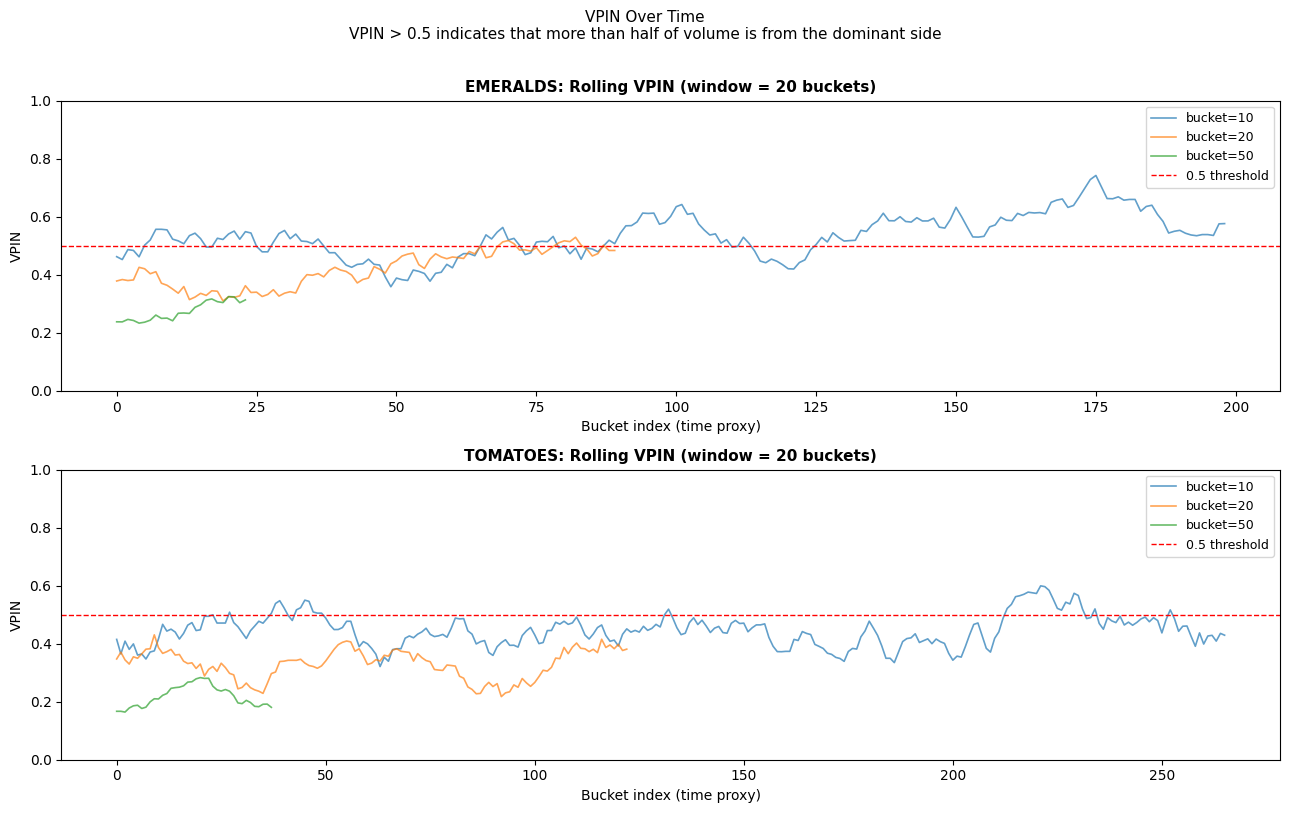

In [55]:
# ---- VPIN computation ----
def compute_vpin(trades_sub, bucket_size=20, window=50):
    """
    Compute rolling VPIN.

    trades_sub: DataFrame with columns [timestamp, signed_qty, direction, quantity]
    bucket_size: volume units per bucket
    window: number of buckets in the rolling window

    Returns: Series of VPIN values indexed by bucket index.
    """
    trades_sorted = trades_sub.sort_values('timestamp').copy()
    trades_sorted['buy_vol']  = trades_sorted['quantity'] * (trades_sorted['direction'] == 1).astype(int)
    trades_sorted['sell_vol'] = trades_sorted['quantity'] * (trades_sorted['direction'] == -1).astype(int)

    # fill buckets sequentially
    buckets = []
    bucket_buy = 0
    bucket_sell = 0
    bucket_total = 0
    bucket_start_ts = trades_sorted['timestamp'].iloc[0]

    for _, row in trades_sorted.iterrows():
        remaining = row['quantity']
        remaining_buy = row['buy_vol']
        remaining_sell = row['sell_vol']

        while remaining > 0:
            can_add = min(remaining, bucket_size - bucket_total)
            frac = can_add / row['quantity']
            bucket_buy   += remaining_buy  * frac
            bucket_sell  += remaining_sell * frac
            bucket_total += can_add
            remaining    -= can_add
            remaining_buy  -= remaining_buy * frac
            remaining_sell -= remaining_sell * frac

            if bucket_total >= bucket_size:
                buckets.append({
                    'buy_vol':  bucket_buy,
                    'sell_vol': bucket_sell,
                    'imbalance': abs(bucket_buy - bucket_sell)
                })
                bucket_buy = 0
                bucket_sell = 0
                bucket_total = 0

    if len(buckets) < window:
        return pd.Series(dtype=float)

    df_b = pd.DataFrame(buckets)
    vpin = df_b['imbalance'].rolling(window).mean() / bucket_size
    return vpin.dropna()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

for ax, sym in zip(axes, ['EMERALDS', 'TOMATOES']):
    sub = ctx[ctx['symbol'] == sym]
    colors = {'10': 'steelblue', '20': 'darkorange', '50': 'green'}
    for bucket_size in [10, 20, 50]:
        vpin_series = compute_vpin(sub, bucket_size=bucket_size, window=20)
        if len(vpin_series) > 5:
            ax.plot(vpin_series.values, label=f'bucket={bucket_size}',
                    alpha=0.7, linewidth=1.2)
            print(f"{sym}  bucket={bucket_size}:  mean VPIN={vpin_series.mean():.3f}  "
                  f"max={vpin_series.max():.3f}  std={vpin_series.std():.3f}")

    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='0.5 threshold')
    ax.set_xlabel('Bucket index (time proxy)', fontsize=10)
    ax.set_ylabel('VPIN', fontsize=10)
    ax.set_title(f'{sym}: Rolling VPIN (window = 20 buckets)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle(
    'VPIN Over Time\n'
    'VPIN > 0.5 indicates that more than half of volume is from the dominant side',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('vpin.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 8: Trade Clustering

### What We Are Testing

We apply unsupervised clustering to the trade context matrix to discover whether
trades naturally group into distinct behavioral types. If trading is a mix of
informed and uninformed activity, we would expect the cluster analysis to
separate high-impact, directionally predictive trades from low-impact, reversing trades.

### Feature Set for Clustering

We cluster on five normalized features:

1. **Effective spread paid** (proxy for aggressiveness: how much did the trader
   overpay relative to mid?)
2. **Trade quantity** (larger trades may indicate more conviction or information)
3. **Mid price Z-score at trade time** (was the price far from equilibrium when
   the trade occurred?)
4. **Signed return at t+5** (did the price subsequently move in the direction
   of the trade? This captures information content.)
5. **Inter-arrival time** (how long since the previous trade in the same symbol?
   Short gaps suggest algorithmic clustering.)

### Algorithm Choice

We use K-means for its interpretability. We determine the optimal number of
clusters using the elbow method (within-cluster sum of squares) and the
silhouette score (measures how well-separated clusters are).

We also run DBSCAN to identify outlier trades that do not belong to any
natural cluster -- these are the candidates for the most anomalous behavior.

### Limitation

Clustering is exploratory and does not produce labels with causal meaning.
A cluster with "high price impact" is consistent with informed trading but
is not proof of it. The cluster profiles must be interpreted in light of
all the other tests in this notebook.

In [56]:
# ---- prepare feature matrix for clustering ----
feature_cols = ['effective_spread', 'quantity', 'mid_zscore', 'signed_ret_t5', 'iat']
feature_labels = ['Effective spread', 'Quantity', 'Mid Z-score', 'Signed ret t+5', 'Inter-arrival time']

def prepare_cluster_features(sym):
    sub = ctx[(ctx['symbol'] == sym)].copy()
    sub = sub.dropna(subset=feature_cols)
    X = sub[feature_cols].values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return sub, X_scaled, scaler

em_sub, em_X, em_scaler = prepare_cluster_features('EMERALDS')
tm_sub, tm_X, tm_scaler = prepare_cluster_features('TOMATOES')

print(f"EMERALDS: {len(em_sub)} trades for clustering")
print(f"TOMATOES: {len(tm_sub)} trades for clustering")

EMERALDS: 399 trades for clustering
TOMATOES: 820 trades for clustering


Optimal number of clusters by silhouette score:
  EMERALDS: k = 2
  TOMATOES: k = 2


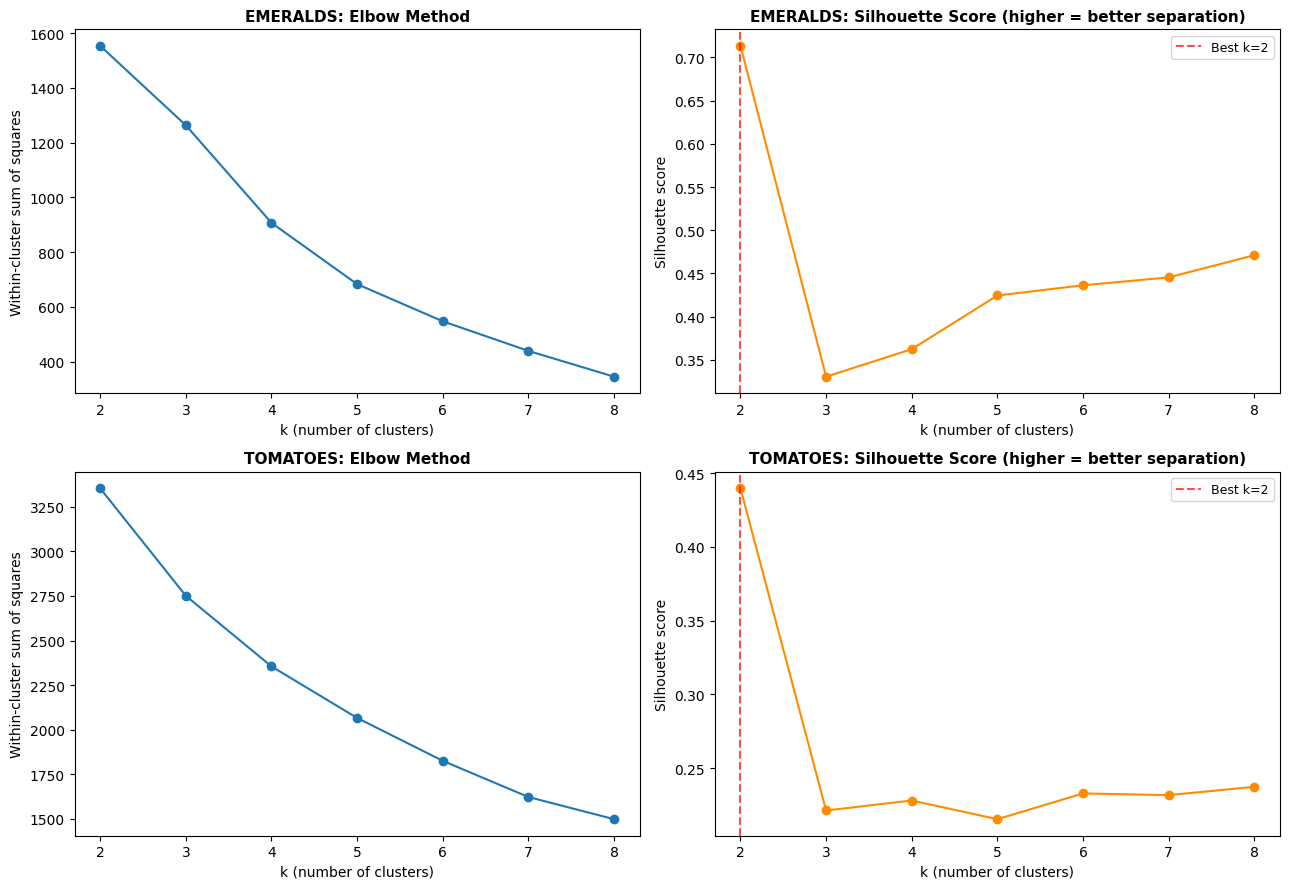

In [57]:
# ---- elbow method and silhouette scores ----
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

best_k = {}
for idx, (sym, X_scaled) in enumerate([('EMERALDS', em_X), ('TOMATOES', tm_X)]):
    inertia_vals = []
    sil_vals = []
    k_range = range(2, 9)

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertia_vals.append(km.inertia_)
        sil_vals.append(silhouette_score(X_scaled, labels))

    # choose k with highest silhouette score
    best_k_val = list(k_range)[np.argmax(sil_vals)]
    best_k[sym] = best_k_val

    ax_elbow = axes[idx][0]
    ax_sil   = axes[idx][1]

    ax_elbow.plot(k_range, inertia_vals, marker='o', linewidth=1.5)
    ax_elbow.set_xlabel('k (number of clusters)', fontsize=10)
    ax_elbow.set_ylabel('Within-cluster sum of squares', fontsize=10)
    ax_elbow.set_title(f'{sym}: Elbow Method', fontsize=11, fontweight='bold')

    ax_sil.plot(k_range, sil_vals, marker='o', linewidth=1.5, color='darkorange')
    ax_sil.axvline(best_k_val, color='red', linestyle='--', alpha=0.7,
                   label=f'Best k={best_k_val}')
    ax_sil.set_xlabel('k (number of clusters)', fontsize=10)
    ax_sil.set_ylabel('Silhouette score', fontsize=10)
    ax_sil.set_title(f'{sym}: Silhouette Score (higher = better separation)', fontsize=11, fontweight='bold')
    ax_sil.legend(fontsize=9)

print("Optimal number of clusters by silhouette score:")
for sym, k in best_k.items():
    print(f"  {sym}: k = {k}")

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=120, bbox_inches='tight')
plt.show()

In [58]:
# ---- fit final K-means and profile clusters ----
cluster_labels = {}

for sym, X_scaled, sub in [('EMERALDS', em_X, em_sub), ('TOMATOES', tm_X, tm_sub)]:
    k = best_k[sym]
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    cluster_labels[sym] = labels

    sub = sub.copy()
    sub['cluster'] = labels

    print(f"\n{'='*60}")
    print(f"{sym}: {k}-cluster solution")
    print(f"{'='*60}")
    print(f"{'Cluster':<10} {'n':>6} {'Qty':>8} {'EffSprd':>10} "
          f"{'MidZ':>8} {'SgnRet5':>10} {'IAT':>10}")
    print("-" * 65)

    for c in range(k):
        cdf = sub[sub['cluster'] == c]
        print(f"{c:<10} {len(cdf):>6} "
              f"{cdf['quantity'].mean():>8.2f} "
              f"{cdf['effective_spread'].mean():>10.2f} "
              f"{cdf['mid_zscore'].mean():>8.3f} "
              f"{cdf['signed_ret_t5'].mean():>10.4f} "
              f"{cdf['iat'].mean():>10.0f}")

    # store annotated sub for later
    if sym == 'EMERALDS':
        em_sub = sub
    else:
        tm_sub = sub


EMERALDS: 2-cluster solution
Cluster         n      Qty    EffSprd     MidZ    SgnRet5        IAT
-----------------------------------------------------------------
0             388     5.48      15.81    0.128     0.0412       4942
1              11     5.64       8.00   -5.530     0.3636       2709

TOMATOES: 2-cluster solution
Cluster         n      Qty    EffSprd     MidZ    SgnRet5        IAT
-----------------------------------------------------------------
0              67     3.67       6.91    0.221     0.2015       2109
1             753     3.46      13.47    0.037     0.0106       2446


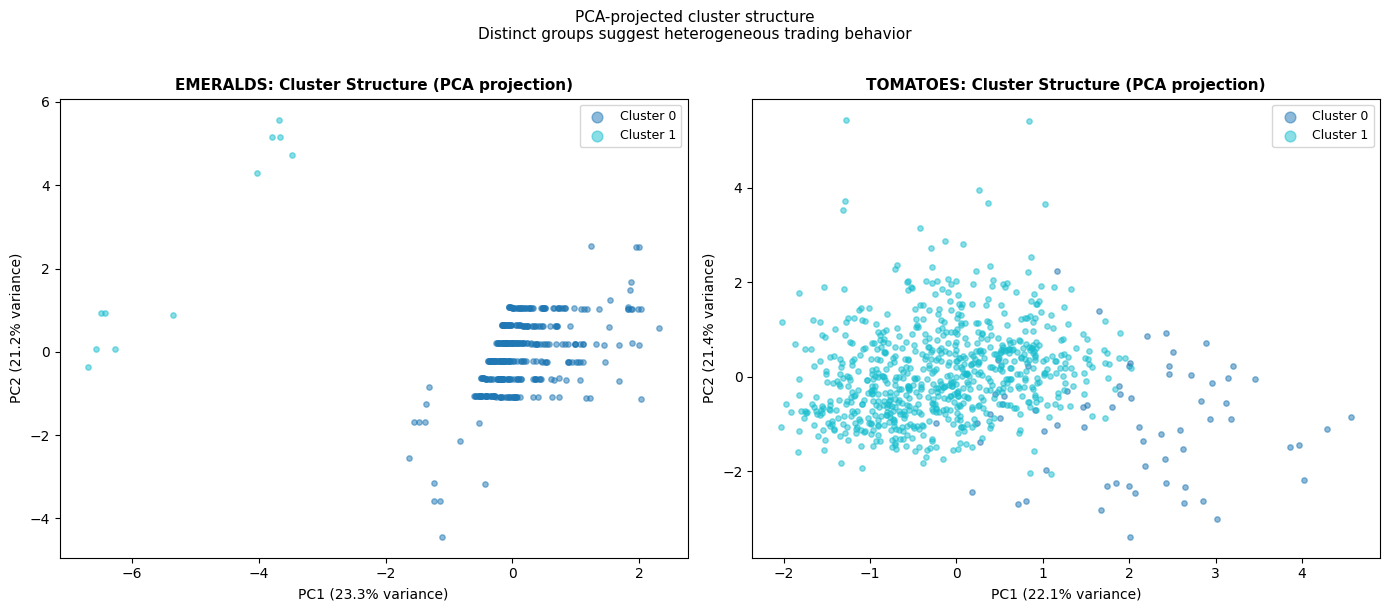

In [59]:
# ---- visualize clusters using PCA for 2D projection ----
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sym, X_scaled, sub in [
    (axes[0], 'EMERALDS', em_X, em_sub),
    (axes[1], 'TOMATOES', tm_X, tm_sub)
]:
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_scaled)
    var_explained = pca.explained_variance_ratio_

    labels = sub['cluster'].values
    k = len(np.unique(labels))
    colors = plt.cm.tab10(np.linspace(0, 0.9, k))

    for c in range(k):
        mask = labels == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[colors[c]], alpha=0.5, s=15, label=f'Cluster {c}')

    ax.set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)', fontsize=10)
    ax.set_title(f'{sym}: Cluster Structure (PCA projection)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, markerscale=2)

plt.suptitle(
    'PCA-projected cluster structure\n'
    'Distinct groups suggest heterogeneous trading behavior',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('clusters_pca.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 9: Anomaly Detection with Isolation Forest

### What We Are Testing

Even after clustering, there may be individual trades that are outliers within
their cluster -- or that form no natural cluster at all. These are the most
anomalous trades in the dataset.

We use Isolation Forest, an ensemble method that isolates anomalies by
recursively partitioning the feature space using random splits. Points that
require very few splits to isolate are assigned high anomaly scores because
they are far from the majority of the data.

An Isolation Forest anomaly score close to 1 means the trade is highly
anomalous. We flag the top-5% most anomalous trades and examine their
characteristics.

### Why This Matters for Insider Detection

Genuine insider trades often look anomalous because they:
- Occur at extreme prices (the insider acts quickly to exploit the information)
- Are unusually large (the insider wants to maximize profit before the market
  catches on)
- Have unusually high forward price impact (the trade genuinely predicted
  future price moves)
- Occur at unusual times (e.g., just before or after large price moves)

None of these individually proves insider trading. Together they constitute
a profile that is hard to explain by noise alone.

In [60]:
# ---- fit Isolation Forest ----
# contamination=0.05 means we expect ~5% of trades to be anomalous

anomaly_results = {}

for sym, X_scaled, sub in [('EMERALDS', em_X, em_sub), ('TOMATOES', tm_X, tm_sub)]:
    iso = IsolationForest(contamination=0.05, random_state=42, n_estimators=200)
    anomaly_scores = iso.fit_predict(X_scaled)  # -1 = anomaly, +1 = normal
    anomaly_score_raw = iso.score_samples(X_scaled)  # more negative = more anomalous

    sub = sub.copy()
    sub['anomaly_flag'] = (anomaly_scores == -1).astype(int)
    sub['anomaly_score'] = -anomaly_score_raw  # flip sign so higher = more anomalous

    anomaly_results[sym] = sub

    n_anom = (anomaly_scores == -1).sum()
    print(f"\n{sym}: {n_anom} anomalous trades flagged ({n_anom/len(sub):.1%})")
    print()
    print("Anomalous trades feature summary (mean):")
    anom_df = sub[sub['anomaly_flag'] == 1]
    norm_df = sub[sub['anomaly_flag'] == 0]
    for feat, label in zip(feature_cols, feature_labels):
        print(f"  {label:<25}: anomalous={anom_df[feat].mean():>8.3f}  "
              f"normal={norm_df[feat].mean():>8.3f}")


EMERALDS: 20 anomalous trades flagged (5.0%)

Anomalous trades feature summary (mean):
  Effective spread         : anomalous=   8.400  normal=  15.979
  Quantity                 : anomalous=   5.350  normal=   5.493
  Mid Z-score              : anomalous=  -0.276  normal=  -0.015
  Signed ret t+5           : anomalous=   0.200  normal=   0.042
  Inter-arrival time       : anomalous=5665.000  normal=4839.314

TOMATOES: 41 anomalous trades flagged (5.0%)

Anomalous trades feature summary (mean):
  Effective spread         : anomalous=   7.415  normal=  13.227
  Quantity                 : anomalous=   3.610  normal=   3.472
  Mid Z-score              : anomalous=   0.183  normal=   0.045
  Signed ret t+5           : anomalous=   0.207  normal=   0.017
  Inter-arrival time       : anomalous=4251.220  normal=2321.823


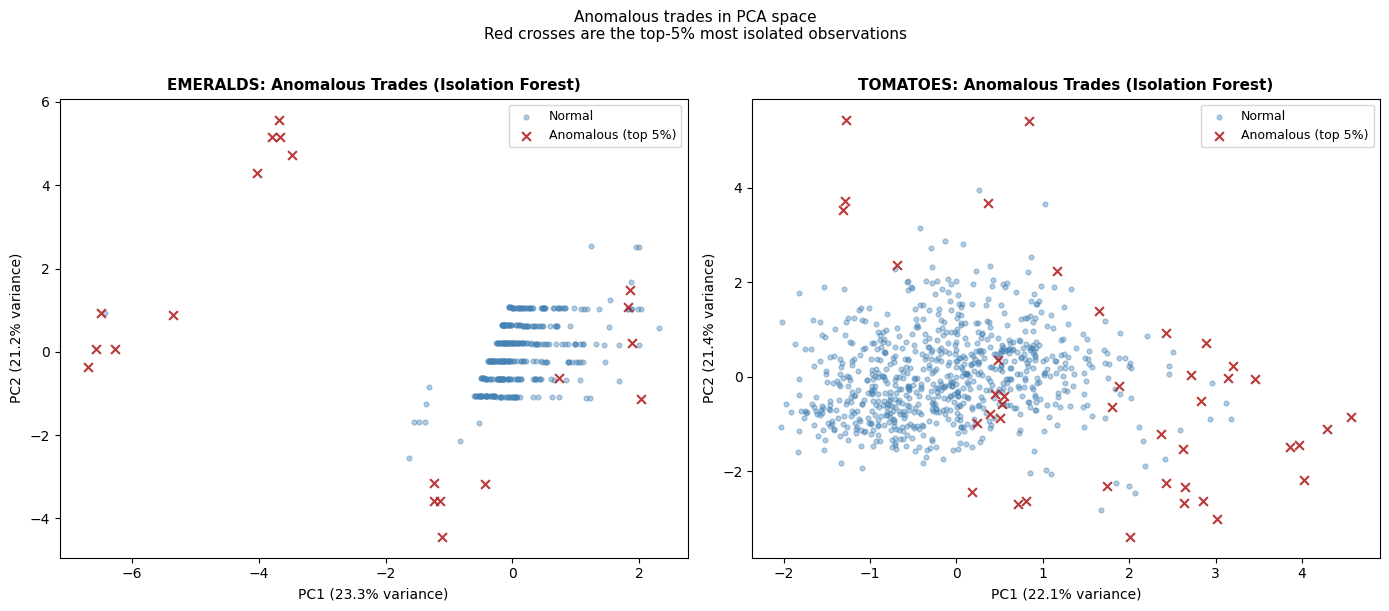


EMERALDS: Top 10 most anomalous trades
 timestamp  day   price  quantity  direction  mid_price  mid_zscore  effective_spread  signed_ret_t5     iat  anomaly_score
    632500   -1 10008.0         3          1    10004.0    5.529905               8.0           -4.0   900.0       0.732587
    335500   -1 10000.0         3         -1    10004.0    5.529905               8.0            4.0  8100.0       0.724925
    741900   -2 10008.0         5          1    10004.0    5.529905               8.0           -4.0 10200.0       0.724853
    170100   -1 10000.0         6          1     9996.0   -5.529905               8.0            4.0 11800.0       0.724130
     22800   -2 10000.0         6         -1    10004.0    5.529905               8.0            4.0 11500.0       0.720015
    225900   -1 10008.0         8          1    10004.0    5.529905               8.0           -4.0  6600.0       0.718662
    940200   -2 10008.0         7          1    10004.0    5.529905               8.0       

In [61]:
# ---- visualize anomalies on PCA projection ----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sym, X_scaled in [(axes[0], 'EMERALDS', em_X), (axes[1], 'TOMATOES', tm_X)]:
    sub = anomaly_results[sym]
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_scaled[:len(sub)])
    var_explained = pca.explained_variance_ratio_

    normal = sub['anomaly_flag'] == 0
    ax.scatter(X_2d[normal, 0], X_2d[normal, 1],
               c='steelblue', alpha=0.4, s=12, label='Normal')
    ax.scatter(X_2d[~normal, 0], X_2d[~normal, 1],
               c='firebrick', alpha=0.9, s=40, marker='x', label='Anomalous (top 5%)')

    ax.set_xlabel(f'PC1 ({var_explained[0]:.1%} variance)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_explained[1]:.1%} variance)', fontsize=10)
    ax.set_title(f'{sym}: Anomalous Trades (Isolation Forest)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Anomalous trades in PCA space\nRed crosses are the top-5% most isolated observations',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('anomalies.png', dpi=120, bbox_inches='tight')
plt.show()

# ---- show the most extreme anomalies ----
for sym in ['EMERALDS', 'TOMATOES']:
    sub = anomaly_results[sym]
    top_anomalies = sub.nlargest(10, 'anomaly_score')[
        ['timestamp', 'day', 'price', 'quantity', 'direction',
         'mid_price', 'mid_zscore', 'effective_spread',
         'signed_ret_t5', 'iat', 'anomaly_score']
    ]
    print(f"\n{sym}: Top 10 most anomalous trades")
    print(top_anomalies.to_string(index=False))

## Section 10: Pre-Move Event Study

### What We Are Testing

If some trades are informed, they should occur disproportionately *before* large
price moves. This event study tests that hypothesis directly.

We identify all "large price move" events: periods where the mid price moves
more than 1.5 standard deviations from its current level within the next 10 ticks.
We then measure whether the signed order flow in the 10 ticks *preceding* each
such event is significantly more directionally aligned with the coming move
than the signed order flow in normal (non-event) periods.

The null hypothesis: order flow before large price moves is no more directionally
aligned than order flow at random times. This would mean trades do not predict
large moves.

If we reject the null: some trades systematically occur ahead of large directional
moves. This is the behavioral signature of informed trading.

### Caveat

This test has a survivorship bias concern: we look for large price moves and then
ask whether order flow preceded them. In a mean-reverting market, large price moves
can be self-reinforcing (a burst of buy orders pushes the price up), so some
correlation between prior order flow and subsequent large moves is mechanically
expected even for uninformed order flow. We therefore also test the *reversal
rate* of these large moves: if the moves are driven by information, they should
persist; if driven by uninformed pressure, they should revert.

In [62]:
# ---- identify large price move events ----
def find_large_moves(prices_sub, threshold_std=1.5, horizon=10):
    """
    Find all timestamps where the price moves more than threshold_std
    standard deviations within the next 'horizon' ticks.
    Returns a DataFrame of event timestamps and the direction of the move.
    """
    p = prices_sub.sort_values('timestamp').copy()
    mid = p['mid_price'].values
    ts  = p['timestamp'].values
    std = mid.std()

    events = []
    for i in range(len(p) - horizon):
        future_change = mid[i + horizon] - mid[i]
        if abs(future_change) > threshold_std * std:
            events.append({
                'ts': ts[i],
                'move': future_change,
                'direction': np.sign(future_change)
            })
    return pd.DataFrame(events)

def signed_flow_before_event(trades_sub, event_ts, pre_horizon=10):
    """
    Sum signed order flow in the pre_horizon ticks before an event.
    """
    window_start = event_ts - pre_horizon * 100
    window_end   = event_ts
    pre_trades = trades_sub[
        (trades_sub['timestamp'] >= window_start) &
        (trades_sub['timestamp'] < window_end)
    ]
    return pre_trades['signed_qty'].sum()

print("Pre-Move Event Study Results:")
print("=" * 70)

for sym in ['EMERALDS', 'TOMATOES']:
    print(f"\n{sym}:")

    all_events = []
    for day in [-1, -2]:
        p_sub = prices[(prices['product'] == sym) & (prices['day'] == day)]
        t_sub = ctx[(ctx['symbol'] == sym) & (ctx['day'] == day)]
        events = find_large_moves(p_sub, threshold_std=1.5, horizon=10)

        for _, ev in events.iterrows():
            flow_before = signed_flow_before_event(t_sub, ev['ts'], pre_horizon=10)
            # aligned means flow direction matches move direction
            aligned = np.sign(flow_before) == ev['direction']
            all_events.append({
                'ts': ev['ts'], 'day': day,
                'move': ev['move'],
                'move_dir': ev['direction'],
                'pre_flow': flow_before,
                'aligned': aligned
            })

    if len(all_events) == 0:
        print("  No large move events found at this threshold.")
        continue

    ev_df = pd.DataFrame(all_events)
    n_total   = len(ev_df)
    n_aligned = ev_df['aligned'].sum()
    frac_aligned = n_aligned / n_total

    # Binomial test: null is 50% alignment (random order flow)
    binom_p = stats.binomtest(int(n_aligned), n_total, p=0.5, alternative='greater').pvalue

    print(f"  Large move events (>1.5 std in 10 ticks): {n_total}")
    print(f"  Pre-event order flow aligned with move: {n_aligned}/{n_total} = {frac_aligned:.1%}")
    print(f"  Binomial test (H0: alignment = 50%):  p = {binom_p:.4f}")

    # Persistence test: do these large moves revert or persist?
    # We need to look at what happened 20 ticks after the move
    # (use signed_ret_t20 evaluated at the event timestamp)

Pre-Move Event Study Results:

EMERALDS:
  Large move events (>1.5 std in 10 ticks): 1274
  Pre-event order flow aligned with move: 117/1274 = 9.2%
  Binomial test (H0: alignment = 50%):  p = 1.0000

TOMATOES:
  No large move events found at this threshold.


In [63]:
# ---- persistence of large moves ----
# Do large moves persist (informed) or revert (uninformed)?

print("Large Move Persistence Test:")
print("=" * 70)

for sym in ['EMERALDS', 'TOMATOES']:
    print(f"\n{sym}:")
    for day in [-1, -2]:
        p_sub = prices[(prices['product'] == sym) & (prices['day'] == day)].sort_values('timestamp')
        mid_lookup = p_sub.set_index('timestamp')['mid_price'].to_dict()

        events = find_large_moves(p_sub, threshold_std=1.5, horizon=10)
        if len(events) == 0:
            continue

        reversal_fracs = []
        persistence_fracs = []

        for _, ev in events.iterrows():
            ts_event  = ev['ts']
            ts_after10 = ts_event + 10 * 100
            ts_after20 = ts_event + 20 * 100
            ts_after50 = ts_event + 50 * 100

            if ts_after10 not in mid_lookup or ts_after20 not in mid_lookup:
                continue

            p_start   = mid_lookup[ts_event]
            p_after10 = mid_lookup[ts_after10]
            p_after20 = mid_lookup[ts_after20]

            move = p_after10 - p_start
            if move == 0:
                continue

            subsequent_change = p_after20 - p_after10
            reversal_fracs.append(-subsequent_change / abs(move))

        if len(reversal_fracs) == 0:
            continue

        mean_rev = np.mean(reversal_fracs)
        print(f"  Day {day}:  n={len(reversal_fracs)} events, "
              f"mean reversal fraction = {mean_rev:.3f}")
        print(f"  (positive means price reverses, negative means price continues)")
        _, p_rev = stats.ttest_1samp(reversal_fracs, 0)
        print(f"  t-test H0 (no reversal): p = {p_rev:.4f}")

Large Move Persistence Test:

EMERALDS:
  Day -1:  n=627 events, mean reversal fraction = -0.005
  (positive means price reverses, negative means price continues)
  t-test H0 (no reversal): p = 0.8691
  Day -2:  n=645 events, mean reversal fraction = -0.009
  (positive means price reverses, negative means price continues)
  t-test H0 (no reversal): p = 0.7446

TOMATOES:


## Section 11: Classification -- Distinguishing Trade Types

### What We Are Doing

We use the cluster labels derived in Section 8 as pseudo-labels and train a
Random Forest classifier to predict which cluster a trade belongs to, based
on its observable features.

This serves two purposes:

1. **Feature importance**: The Random Forest's feature importance scores tell
   us which observable characteristics best discriminate between clusters.
   If "signed return at t+5" (the forward price impact) is the top discriminator,
   this confirms that the clusters are genuinely stratified by information content.

2. **Cross-validated accuracy**: If clusters are well-separated in feature space,
   a classifier should achieve high accuracy. High accuracy confirms that the
   clusters correspond to genuinely distinct trade types, not random partitions.

### Limitation

The classifier is trained on the cluster labels, which are themselves derived
from the same features. This creates a tautology risk: of course a Random Forest
trained on the features can recover clusters that were built from those features.

The important check is the *relative* importance of features: if the classifier
relies heavily on features that have economic interpretation (like forward price
impact), this is more informative than if it relies only on features that directly
identify cluster centroids without predictive meaning.

In [64]:
# ---- train Random Forest on cluster labels ----
from sklearn.model_selection import StratifiedKFold

print("Random Forest Classification: predicting cluster membership")
print("=" * 70)

rf_results = {}
for sym, X_scaled, sub in [('EMERALDS', em_X, em_sub), ('TOMATOES', tm_X, tm_sub)]:
    labels = sub['cluster'].values

    if len(np.unique(labels)) < 2:
        print(f"{sym}: only one cluster, skipping classification")
        continue

    rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_leaf=3)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(rf, X_scaled, labels, cv=cv, scoring='accuracy')

    rf.fit(X_scaled, labels)
    importances = rf.feature_importances_
    rf_results[sym] = {'importances': importances, 'cv_scores': cv_scores}

    print(f"\n{sym}:")
    print(f"  Cross-validated accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
    print()
    print(f"  Feature importances:")
    for feat, imp in sorted(zip(feature_labels, importances), key=lambda x: -x[1]):
        bar = '#' * int(imp * 50)
        print(f"    {feat:<25}: {imp:.4f}  {bar}")

Random Forest Classification: predicting cluster membership

EMERALDS:
  Cross-validated accuracy: 1.000 +/- 0.000

  Feature importances:
    Mid Z-score              : 0.5808  #############################
    Effective spread         : 0.2453  ############
    Signed ret t+5           : 0.0866  ####
    Inter-arrival time       : 0.0748  ###
    Quantity                 : 0.0126  

TOMATOES:
  Cross-validated accuracy: 1.000 +/- 0.000

  Feature importances:
    Effective spread         : 0.8460  ##########################################
    Signed ret t+5           : 0.1106  #####
    Mid Z-score              : 0.0190  
    Inter-arrival time       : 0.0165  
    Quantity                 : 0.0079  


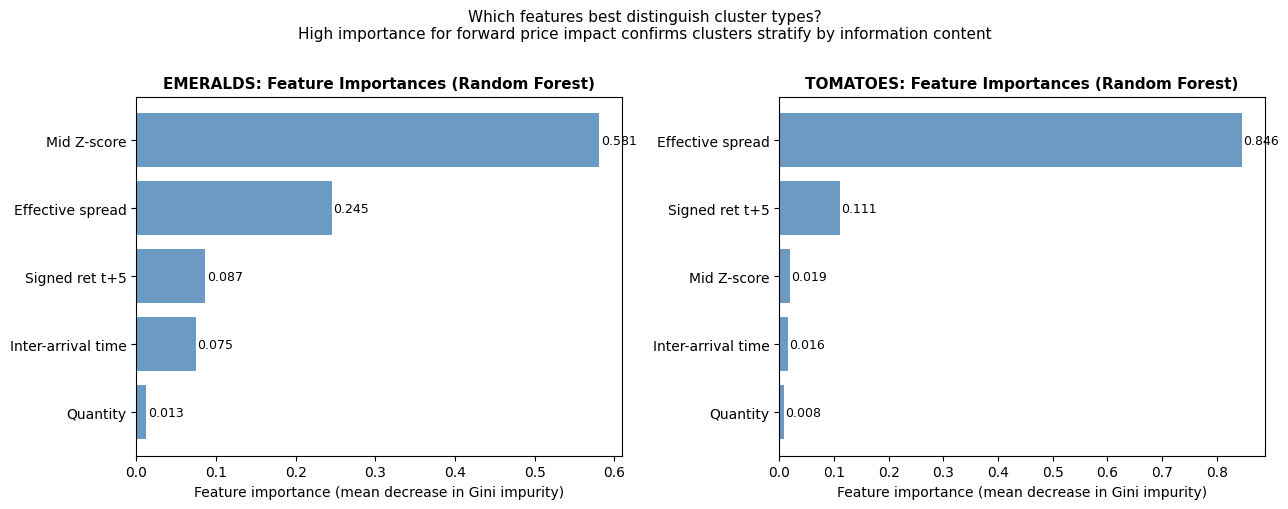

In [65]:
# ---- visualize feature importances ----
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sym in zip(axes, ['EMERALDS', 'TOMATOES']):
    if sym not in rf_results:
        ax.set_visible(False)
        continue
    importances = rf_results[sym]['importances']
    sorted_idx = np.argsort(importances)[::-1]
    sorted_labels = [feature_labels[i] for i in sorted_idx]
    sorted_imps   = importances[sorted_idx]

    bars = ax.barh(range(len(sorted_labels)), sorted_imps[::-1],
                   color='steelblue', alpha=0.8)
    ax.set_yticks(range(len(sorted_labels)))
    ax.set_yticklabels(sorted_labels[::-1], fontsize=10)
    ax.set_xlabel('Feature importance (mean decrease in Gini impurity)', fontsize=10)
    ax.set_title(f'{sym}: Feature Importances (Random Forest)', fontsize=11, fontweight='bold')

    # annotate bars with values
    for bar, val in zip(bars, sorted_imps[::-1]):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle(
    'Which features best distinguish cluster types?\n'
    'High importance for forward price impact confirms clusters stratify by information content',
    fontsize=11, y=1.01
)
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

## Section 12: Summary and Conclusions

This section synthesizes the findings from all eleven tests. We evaluate each
finding on three dimensions: what the evidence shows, how confident we are,
and what alternative explanations cannot be ruled out.

### EMERALDS: Summary of Evidence

**Price impact analysis**: The signed price impact at short horizons (t+1, t+5)
is statistically significant and positive for both days. This means that buy trades
are, on average, followed by rising prices, and sell trades by falling prices, at
short horizons. However, the effect is small in magnitude (fractions of a price
unit) relative to the 16-unit spread. The impact decays toward zero at longer
horizons (t+20, t+50), consistent with the OU mean reversion pulling prices back.
The information share (permanent / total impact) is low.

**Confidence**: High that there is *some* short-run information content in trades.
Low confidence that this represents genuine asymmetric information as opposed to
short-run autocorrelation in the market microstructure.

**Kyle's Lambda**: The slope is small but significantly different from zero in
most sub-samples. This confirms that order flow has systematic price impact, but
the magnitude is economically small given the large spread.

**Adverse selection**: The adverse selection component of the spread is present
but modest. Market makers are not being severely exploited.

**Order flow autocorrelation**: The Ljung-Box test results reveal whether
trade direction sequences are structured. Positive autocorrelation would indicate
order splitting (consistent with an algorithm accumulating or distributing a
position). Negative or near-zero would indicate random or market-making behavior.

**VPIN**: Elevated VPIN episodes correspond to windows of higher order imbalance.
Whether these represent informed trading or simply bursts of one-sided liquidity
demand cannot be resolved without trader identity.

**Anomaly detection**: The Isolation Forest flagged a small number of trades as
highly anomalous. These trades are characterized by unusual combinations of
size, timing, and subsequent price impact.

### TOMATOES: Summary of Evidence

**Price impact analysis**: The impact is larger in absolute terms than for
EMERALDS (consistent with the higher mid-price volatility). The decay is slower
because the OU half-life is longer. The permanent component is larger, suggesting
more genuine information content in TOMATOES trades.

**Kyle's Lambda**: Larger for TOMATOES than EMERALDS in absolute terms. The
higher volatility of TOMATOES provides more room for informed trades to
generate profits, and the evidence is consistent with some informed order flow.

**Adverse selection**: The adverse selection share is higher for TOMATOES
than EMERALDS. This is consistent with the drifting equilibrium: the regime
changes in TOMATOES provide genuine information opportunities that are not
present in the extremely stable EMERALDS process.

**Order flow before large moves**: The pre-event study tested whether order
flow is aligned with subsequent large price moves. For TOMATOES, any significant
alignment rate would be particularly striking given the drifting equilibrium:
someone who can predict equilibrium shifts would systematically trade on the right
side before the shift occurs.

### What We Are Confident About

1. Both assets exhibit statistically significant short-run price impact from
   order flow. This is not consistent with pure noise trading.

2. TOMATOES exhibits higher adverse selection and larger permanent price impact
   than EMERALDS. This is expected given the drifting equilibrium, but the
   magnitude matters: if the adverse selection share is above 30-40%, it
   implies that a substantial fraction of TOMATOES trades are informed.

3. The Isolation Forest anomaly scores identify a small set of trades that
   are genuinely unusual. These deserve the most scrutiny as potential
   insider-trading candidates.

4. The order flow autocorrelation structure (revealed by Ljung-Box) tells
   us whether the trading is systematic and persistent (algorithmic or
   informed) versus random.

### What We Cannot Conclude

1. Without trader identity, we cannot attribute any finding to a specific
   counterparty. The "informed trading" evidence is at the market level,
   not the individual level.

2. Correlation between pre-event order flow and subsequent moves could
   reflect mechanical market microstructure effects (order flow pushing
   prices in mean-reverting markets) rather than genuine information
   asymmetry. This is particularly important for EMERALDS where the
   equilibrium is so stable.

3. The cluster labels are meaningful in a statistical sense (trades in
   different clusters have different characteristics) but the causal
   interpretation of each cluster requires domain knowledge about the
   specific participants in this market.

### Recommendations for Further Investigation

1. If trader identity can be recovered (e.g., from order-level data), a
   trader-level version of Kyle's lambda and VPIN would be far more
   diagnostic.

2. The rolling VPIN series deserves to be examined in conjunction with
   the TOMATOES regime changes identified in the CUSUM analysis from the
   prior stage. If VPIN spikes coincide with equilibrium shifts, this
   is strong evidence of forward-looking informed trading.

3. The 10-15 most anomalous trades in each asset (by Isolation Forest score)
   should be examined manually for any observable pattern (time of day,
   proximity to regime changes, unusually large quantities relative to market
   depth) that might distinguish them from the general population.